# Plotting con Python — Ejercicios

Resolución de los **9 ejercicios** y del **bonus** de los taxis de Nueva York
del notebook de clase `intro_to_plotting`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

---

## 5. Ejercicios

### Ejercicio 1 — Carga el dataset `tips` y muestra las primeras 5 filas

In [2]:
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Ejercicio 2 — Gráfico de dispersión de `total_bill` y `tip`

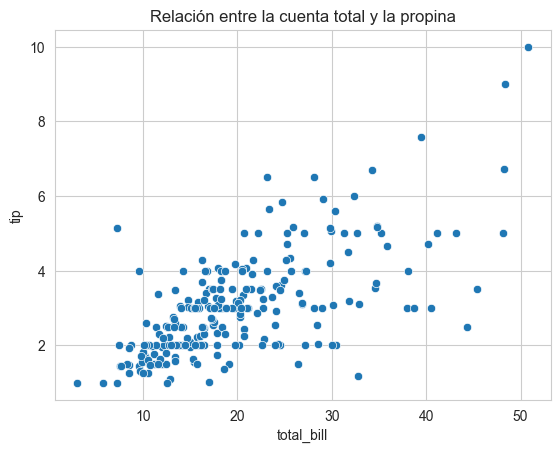

Vemos una relación positiva: a mayor importe de la cuenta, mayor tiende a ser la propina.


In [3]:
ax = sns.scatterplot(x='total_bill', y='tip', data=tips_df)
ax.set_title('Relación entre la cuenta total y la propina')
plt.show()
print('Vemos una relación positiva: a mayor importe de la cuenta, mayor tiende a ser la propina.')

### Ejercicio 3 — Histograma de `total_bill`

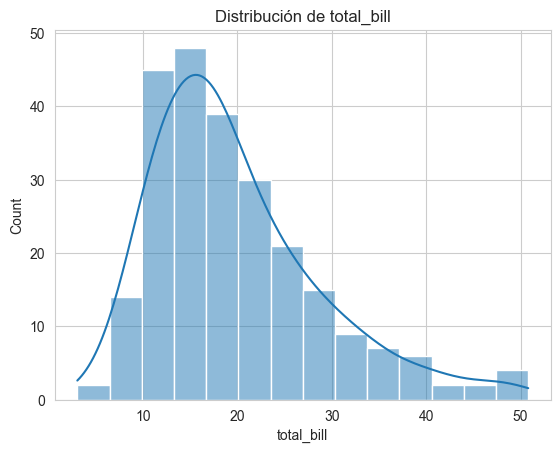

La cuenta media es de 19.79 dólares.


In [4]:
ax = sns.histplot(x='total_bill', data=tips_df, kde=True)
ax.set_title('Distribución de total_bill')
plt.show()
print(f'La cuenta media es de {tips_df["total_bill"].mean():.2f} dólares.')

### Ejercicio 4 — Gráfico de barras con la cantidad de propinas por día

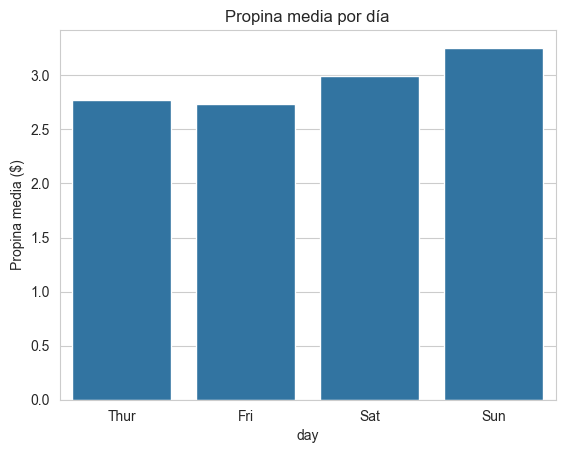

La propina media los Thur fue de 2.77 dólares.
La propina media los Fri fue de 2.73 dólares.
La propina media los Sat fue de 2.99 dólares.
La propina media los Sun fue de 3.26 dólares.


In [5]:
ax = sns.barplot(x='day', y='tip', data=tips_df, estimator='mean', errorbar=None)
ax.set_title('Propina media por día')
ax.set_ylabel('Propina media ($)')
plt.show()

mean_tip_by_day = tips_df.groupby('day', observed=True)['tip'].mean()
for day, avg in mean_tip_by_day.items():
    print(f'La propina media los {day} fue de {avg:.2f} dólares.')

### Ejercicio 5 — Relación entre el número de comensales y la propina

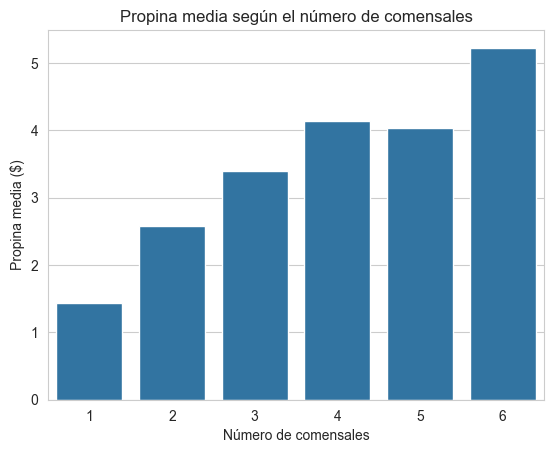

A mayor número de comensales, mayor es la propina media.


In [6]:
ax = sns.barplot(x='size', y='tip', data=tips_df, estimator='mean', errorbar=None)
ax.set_title('Propina media según el número de comensales')
ax.set_xlabel('Número de comensales')
ax.set_ylabel('Propina media ($)')
plt.show()
print('A mayor número de comensales, mayor es la propina media.')

### Ejercicio 6 — Scatterplot de `total_bill` y `tip` con título y etiquetas

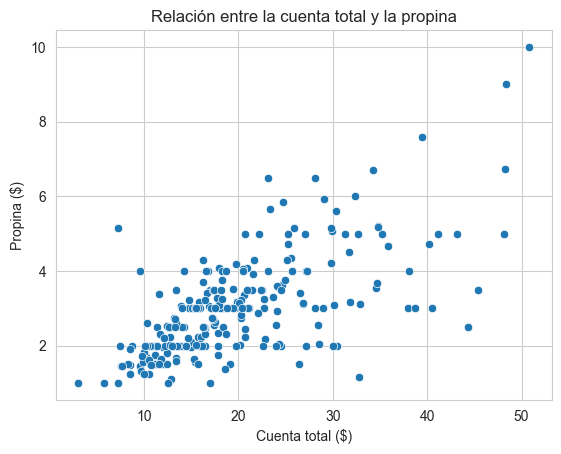

In [7]:
ax = sns.scatterplot(x='total_bill', y='tip', data=tips_df)
ax.set_title('Relación entre la cuenta total y la propina')
ax.set_xlabel('Cuenta total ($)')
ax.set_ylabel('Propina ($)')
plt.show()

### Ejercicio 7 — Gráfico de líneas de `total_bill` y `tip` con línea discontinua y marcadores en círculo

Para personalizar el estilo de la línea (`linestyle='--'`) y los marcadores (`marker='o'`)
recurrimos directamente a `matplotlib`, que ofrece más control que `seaborn` para este caso.

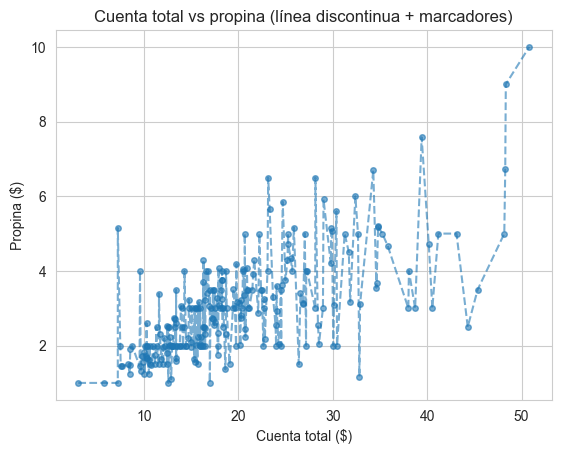

In [8]:
fig, ax = plt.subplots()
sorted_tips_df = tips_df.sort_values('total_bill')
ax.plot(
    sorted_tips_df['total_bill'],
    sorted_tips_df['tip'],
    linestyle='--',
    marker='o',
    markersize=4,
    alpha=0.6,
)
ax.set_title('Cuenta total vs propina (línea discontinua + marcadores)')
ax.set_xlabel('Cuenta total ($)')
ax.set_ylabel('Propina ($)')
plt.show()

### Ejercicio 8 — Figura con dos subplots: histogramas de `total_bill` y `tip`

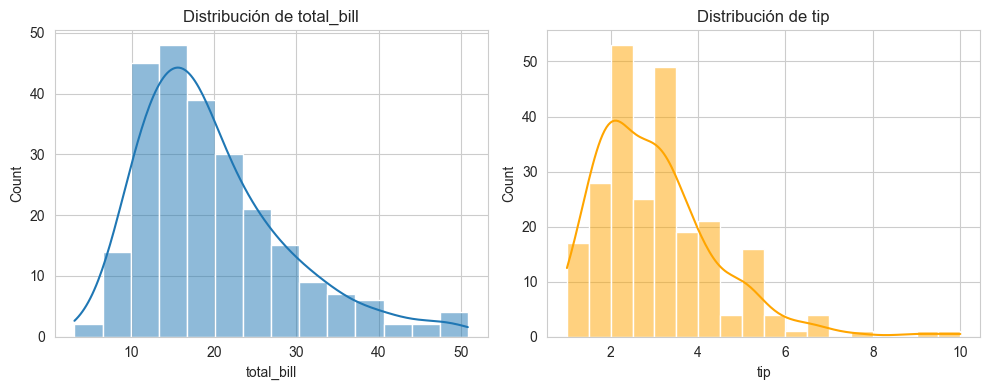

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(tips_df['total_bill'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de total_bill')

sns.histplot(tips_df['tip'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución de tip')

plt.tight_layout()
plt.show()

### Ejercicio 9 — Guarda un scatter de `total_bill` y `tip` como `scatter_plot.png`

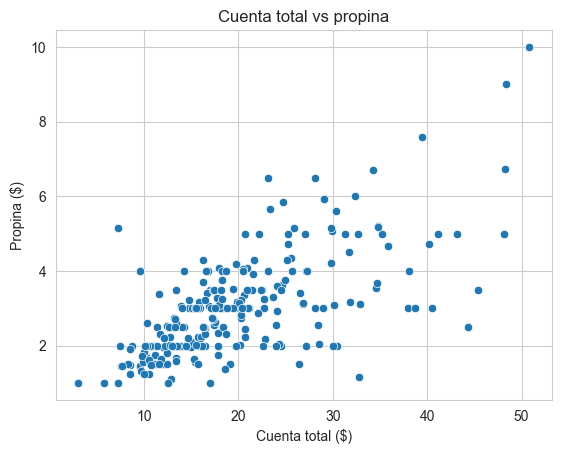

Imagen guardada como scatter_plot.png


In [10]:
fig, ax = plt.subplots()
sns.scatterplot(x='total_bill', y='tip', data=tips_df, ax=ax)
ax.set_title('Cuenta total vs propina')
ax.set_xlabel('Cuenta total ($)')
ax.set_ylabel('Propina ($)')
fig.savefig('scatter_plot.png')
plt.show()
print('Imagen guardada como scatter_plot.png')

---

## BONUS — Taxis de Nueva York

Cargamos el dataset de los taxis de Nueva York que viene incluido en `seaborn`.

In [11]:
taxis_df = sns.load_dataset('taxis')
taxis_df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### B1 — ¿Cómo se distribuyen las distancias de los viajes?

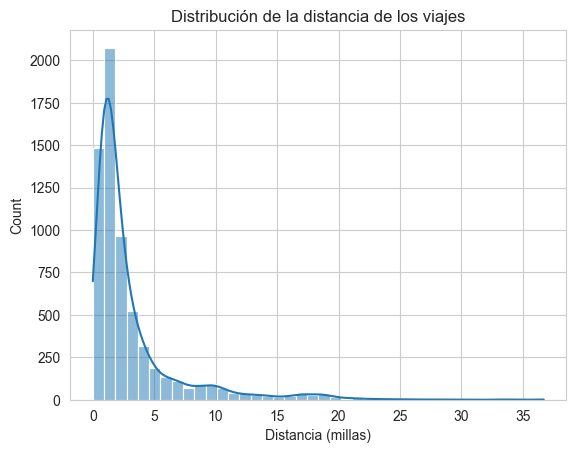

La distancia media de los viajes es de 3.02 millas.
La mayoría de los viajes son cortos (mediana de 1.64 millas).


In [12]:
ax = sns.histplot(taxis_df['distance'], bins=40, kde=True)
ax.set_title('Distribución de la distancia de los viajes')
ax.set_xlabel('Distancia (millas)')
plt.show()
print(f'La distancia media de los viajes es de {taxis_df["distance"].mean():.2f} millas.')
print(f'La mayoría de los viajes son cortos (mediana de {taxis_df["distance"].median():.2f} millas).')

### B2 — Relación entre la distancia del viaje y la tarifa

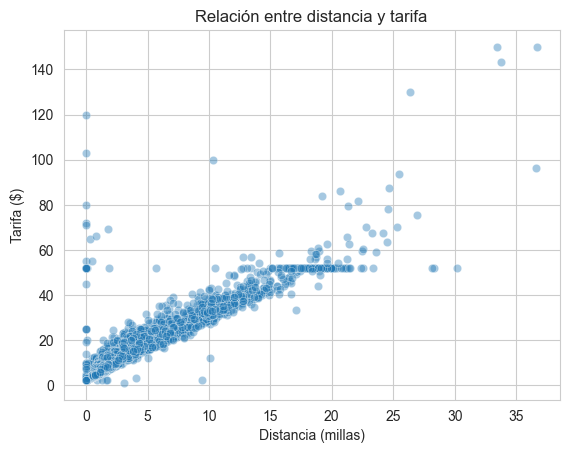

La correlación entre distancia y tarifa es de 0.92: relación lineal positiva fuerte.


In [13]:
ax = sns.scatterplot(x='distance', y='fare', data=taxis_df, alpha=0.4)
ax.set_title('Relación entre distancia y tarifa')
ax.set_xlabel('Distancia (millas)')
ax.set_ylabel('Tarifa ($)')
plt.show()

correlation = taxis_df[['distance', 'fare']].corr().iloc[0, 1]
print(f'La correlación entre distancia y tarifa es de {correlation:.2f}: relación lineal positiva fuerte.')

### B3 — Promedio de las propinas por cada zona de recogida (top 10)

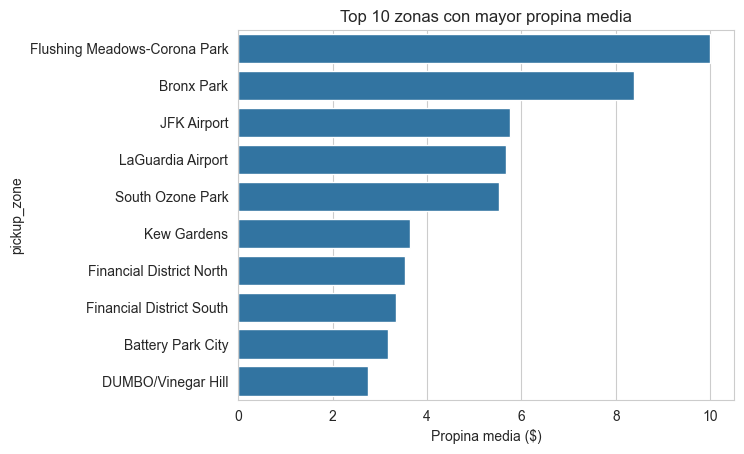

La zona con mayor propina media es Flushing Meadows-Corona Park con 10.00 dólares.


In [14]:
avg_tip_by_zone = (
    taxis_df.groupby('pickup_zone')['tip']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax = sns.barplot(x=avg_tip_by_zone.values, y=avg_tip_by_zone.index, orient='h')
ax.set_title('Top 10 zonas con mayor propina media')
ax.set_xlabel('Propina media ($)')
plt.show()
print(f'La zona con mayor propina media es {avg_tip_by_zone.index[0]} con {avg_tip_by_zone.iloc[0]:.2f} dólares.')

### B4 — Cantidad de pasajeros por barrio (borough) de recogida

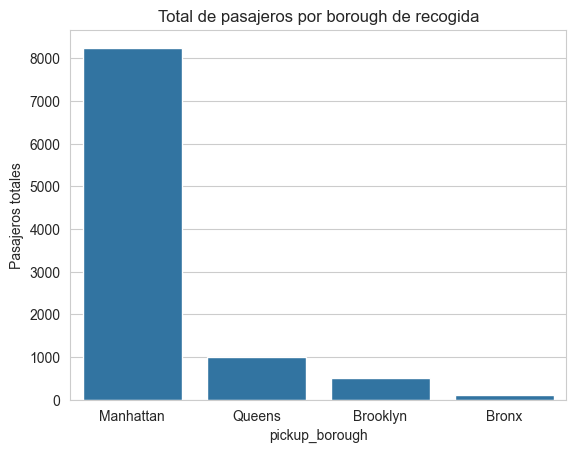

En Manhattan se recogieron 8250 pasajeros en total.
En Queens se recogieron 1001 pasajeros en total.
En Brooklyn se recogieron 502 pasajeros en total.
En Bronx se recogieron 118 pasajeros en total.


In [15]:
passengers_by_borough = taxis_df.groupby('pickup_borough')['passengers'].sum().sort_values(ascending=False)
ax = sns.barplot(x=passengers_by_borough.index, y=passengers_by_borough.values)
ax.set_title('Total de pasajeros por borough de recogida')
ax.set_ylabel('Pasajeros totales')
plt.show()
for borough, total in passengers_by_borough.items():
    print(f'En {borough} se recogieron {int(total)} pasajeros en total.')

### B5 — Relación entre el número de pasajeros y la tarifa total

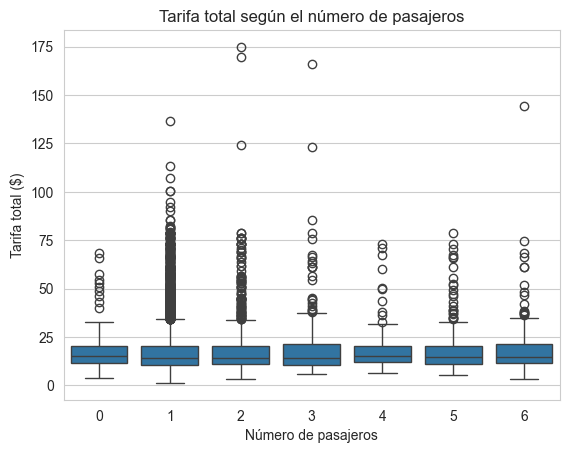

El número de pasajeros no afecta de forma clara a la tarifa total: las distribuciones son muy parecidas.


In [16]:
ax = sns.boxplot(x='passengers', y='total', data=taxis_df)
ax.set_title('Tarifa total según el número de pasajeros')
ax.set_xlabel('Número de pasajeros')
ax.set_ylabel('Tarifa total ($)')
plt.show()
print('El número de pasajeros no afecta de forma clara a la tarifa total: las distribuciones son muy parecidas.')

### B6 — Métodos de pago más comunes

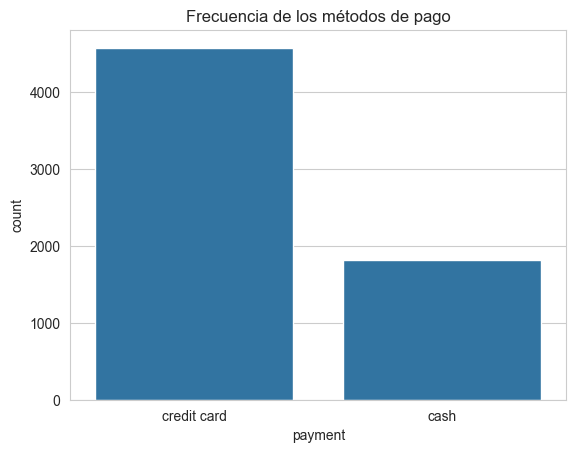

El método de pago más común es "credit card" con 4577 viajes.


In [17]:
ax = sns.countplot(x='payment', data=taxis_df, order=taxis_df['payment'].value_counts().index)
ax.set_title('Frecuencia de los métodos de pago')
plt.show()
payment_counts = taxis_df['payment'].value_counts()
print(f'El método de pago más común es "{payment_counts.index[0]}" con {payment_counts.iloc[0]} viajes.')

### B7 — Variación de las tarifas según el barrio de recogida

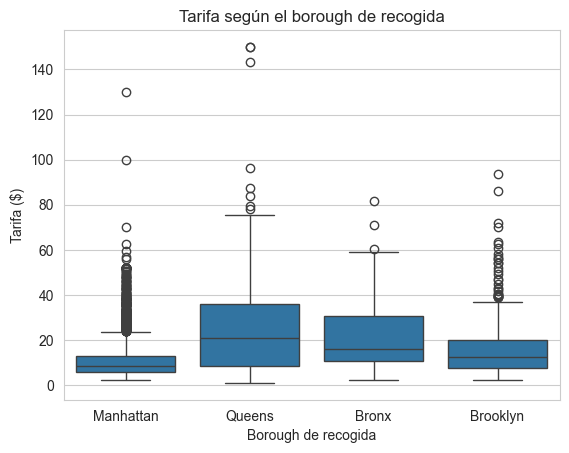

La tarifa media en Queens es de 24.93 dólares.
La tarifa media en Bronx es de 21.00 dólares.
La tarifa media en Brooklyn es de 16.52 dólares.
La tarifa media en Manhattan es de 11.15 dólares.


In [18]:
ax = sns.boxplot(x='pickup_borough', y='fare', data=taxis_df)
ax.set_title('Tarifa según el borough de recogida')
ax.set_xlabel('Borough de recogida')
ax.set_ylabel('Tarifa ($)')
plt.show()

mean_fare_by_borough = taxis_df.groupby('pickup_borough')['fare'].mean().sort_values(ascending=False)
for borough, avg in mean_fare_by_borough.items():
    print(f'La tarifa media en {borough} es de {avg:.2f} dólares.')

### B8 — ¿Qué método de pago recibe las mayores propinas?

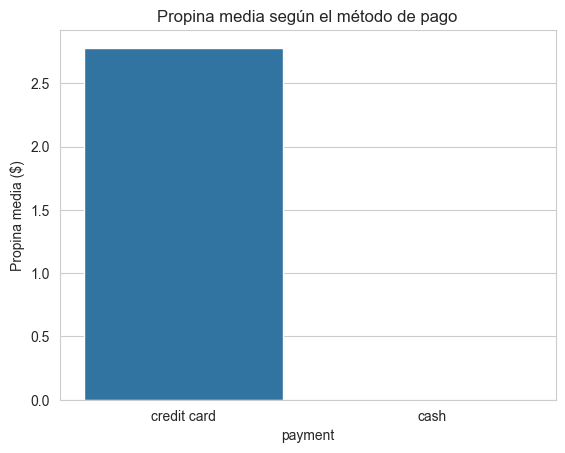

El método de pago que recibe las mayores propinas es "credit card" con 2.78 dólares.


In [19]:
mean_tip_by_payment = taxis_df.groupby('payment')['tip'].mean().sort_values(ascending=False)
ax = sns.barplot(x=mean_tip_by_payment.index, y=mean_tip_by_payment.values)
ax.set_title('Propina media según el método de pago')
ax.set_ylabel('Propina media ($)')
plt.show()
print(f'El método de pago que recibe las mayores propinas es "{mean_tip_by_payment.index[0]}" con {mean_tip_by_payment.iloc[0]:.2f} dólares.')

### B9 — Diferencias en las tarifas totales según el color del taxi

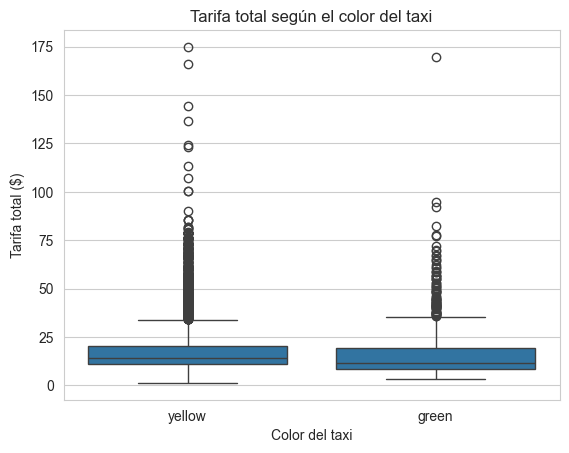

La tarifa total media para los taxis green es de 16.48 dólares.
La tarifa total media para los taxis yellow es de 18.88 dólares.


In [20]:
ax = sns.boxplot(x='color', y='total', data=taxis_df)
ax.set_title('Tarifa total según el color del taxi')
ax.set_xlabel('Color del taxi')
ax.set_ylabel('Tarifa total ($)')
plt.show()

mean_total_by_color = taxis_df.groupby('color')['total'].mean()
for color, avg in mean_total_by_color.items():
    print(f'La tarifa total media para los taxis {color} es de {avg:.2f} dólares.')

### B10 — Peajes según el borough de destino

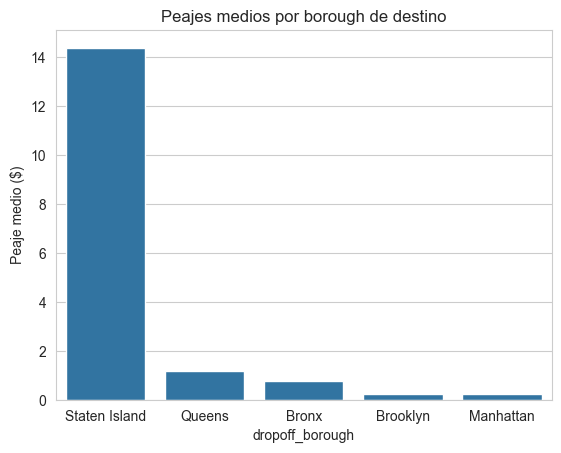

El peaje medio cuando el destino es Staten Island es de 14.40 dólares.
El peaje medio cuando el destino es Queens es de 1.16 dólares.
El peaje medio cuando el destino es Bronx es de 0.77 dólares.
El peaje medio cuando el destino es Brooklyn es de 0.24 dólares.
El peaje medio cuando el destino es Manhattan es de 0.22 dólares.


In [21]:
mean_tolls_by_dropoff = taxis_df.groupby('dropoff_borough')['tolls'].mean().sort_values(ascending=False)
ax = sns.barplot(x=mean_tolls_by_dropoff.index, y=mean_tolls_by_dropoff.values)
ax.set_title('Peajes medios por borough de destino')
ax.set_ylabel('Peaje medio ($)')
plt.show()
for borough, avg in mean_tolls_by_dropoff.items():
    print(f'El peaje medio cuando el destino es {borough} es de {avg:.2f} dólares.')

### B11 — Distancia media de los viajes según el borough de destino

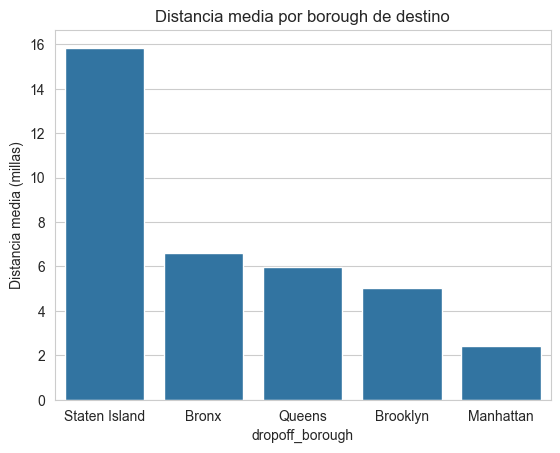

La distancia media de los viajes con destino a Staten Island es de 15.86 millas.
La distancia media de los viajes con destino a Bronx es de 6.61 millas.
La distancia media de los viajes con destino a Queens es de 5.96 millas.
La distancia media de los viajes con destino a Brooklyn es de 5.03 millas.
La distancia media de los viajes con destino a Manhattan es de 2.39 millas.


In [22]:
mean_distance_by_dropoff = taxis_df.groupby('dropoff_borough')['distance'].mean().sort_values(ascending=False)
ax = sns.barplot(x=mean_distance_by_dropoff.index, y=mean_distance_by_dropoff.values)
ax.set_title('Distancia media por borough de destino')
ax.set_ylabel('Distancia media (millas)')
plt.show()
for borough, avg in mean_distance_by_dropoff.items():
    print(f'La distancia media de los viajes con destino a {borough} es de {avg:.2f} millas.')